# 0 準備
!!!ランタイムのハードウェアアクセラレータをGPUにすること!!!


## 0.1 ライブラリのインストール

In [1]:
# リポジトリ
!git clone https://github.com/nu-dialogue/clip-prefix-caption-jp.git
%cd clip-prefix-caption-jp


# 必要ライブラリインストール
!pip install git+https://github.com/openai/CLIP.git
!pip install git+https://github.com/rinnakk/japanese-clip.git
!pip install scikit-image torch transformers sentencepiece

Cloning into 'clip-prefix-caption-jp'...
remote: Enumerating objects: 1983, done.
remote: Total 1983 (delta 0), reused 0 (delta 0), pack-reused 1983
Receiving objects: 100% (1983/1983), 739.32 MiB | 28.57 MiB/s, done.
Resolving deltas: 100% (108/108), done.
Checking out files: 100% (1797/1797), done.
/content/clip-prefix-caption-jp
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-pj2zhylt
  Running command git clone -q https://github.com/openai/CLIP.git /tmp/pip-req-build-pj2zhylt
     |████████████████████████████████| 53 kB 1.3 MB/s 
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369408 sha256=de7b5f66c15b43ac0c39b9b8588205afa2ade253afa39e441969d82e5a9c7b53
  Stored in directory: /tmp/pip-ephem-wheel-cache-j31bphc6/wheels/ab/4f/3a/5e51521b55997aa6f0690e095c08824219753128ce8d9969a3
Successfully built clip
Looking in indexes: https://pypi.org/simple, 

## 0.2 ライブラリのインポート

In [6]:
import json
import os
import sys
import random
import torch
import argparse
from IPython.display import display
from google.colab import files
from huggingface_hub import hf_hub_download

from inference import Predictor
from model import build_models_from_pretrained
from train import set_default_args_to_parser, train

# 後で使う関数も作っておく
def upload_file():
  uploaded = files.upload()
  if not uploaded:
    image_fpath = ''
  elif len(uploaded) == 1:
    image_fpath = list(uploaded.keys())[0]
  else:
    raise RuntimeError("1度に1枚まで")
  return image_fpath

pretrained_repo_id = "nu-dialogue/sfcoco2022-clipcap"

# 1 COCOで学習したモデル

## 1.1 学習済みモデルのダウンロード

In [7]:
_ = hf_hub_download(repo_id=pretrained_repo_id, filename="coco-gpt_medium-en_clip_b32-transformer-finetune-ep10-bs48-lr2e-05/args.json")
coco_checkpoint_fpath = hf_hub_download(repo_id=pretrained_repo_id, filename="coco-gpt_medium-en_clip_b32-transformer-finetune-ep10-bs48-lr2e-05/004.pt")

Downloading:   0%|          | 0.00/764 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.66G [00:00<?, ?B/s]

## 1.2 学習済みモデルの読み込み

In [8]:
cap_model, cap_tokenizer, clip_model, clip_preprocess = build_models_from_pretrained(coco_checkpoint_fpath)
coco_predictor = Predictor(cap_model=cap_model, cap_tokenizer=cap_tokenizer,
                           clip_model=clip_model, clip_preprocess=clip_preprocess)

Downloading:   0%|          | 0.00/799 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

Train both prefix and GPT
Resume pretrained weights from /root/.cache/huggingface/hub/models--nu-dialogue--sfcoco2022-clipcap/snapshots/8b742bc645f73e5673317c4930aa78d53ed95ef9/coco-gpt_medium-en_clip_b32-transformer-finetune-ep10-bs48-lr2e-05/004.pt


Downloading:   0%|          | 0.00/806k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/153 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/282 [00:00<?, ?B/s]

100%|███████████████████████████████████████| 338M/338M [00:08<00:00, 43.9MiB/s]


## 1.3 テスト画像の選択

In [ ]:
#@markdown ### 好きな画像をアップロードする場合
#@markdown ローカルにある画像を使いたい場合は，このセルを実行してアップロードしてください．
#@markdown アップロードした画像はカレントディレクトリ直下に吐き出されます．

image_fpath = upload_file()

In [15]:
#@markdown ### テスト画像リストから選ぶ場合
#@markdown テスト画像リストの画像を使用する場合は，このセルを実行して1枚選択してください．

# テスト画像ファイルリスト読込
TEST_IMAGE_FNAME_LIST = json.load(open("data/sfcoco2021/processed-en_clip_b32/test_list.json"))

# 1枚選択
image_fname = TEST_IMAGE_FNAME_LIST[1] # 1は福沢諭吉像
# image_fname = random.choice(TEST_IMAGE_FNAME_LIST)

image_fpath = os.path.join("data/sfcoco2021/images", image_fname)

## 1.4 キャプション生成

/usr/local/lib/python3.8/dist-packages/transformers/models/t5/tokenization_t5.py:226: UserWarning: This sequence already has </s>. In future versions this behavior may lead to duplicated eos tokens being added.
  warnings.warn(


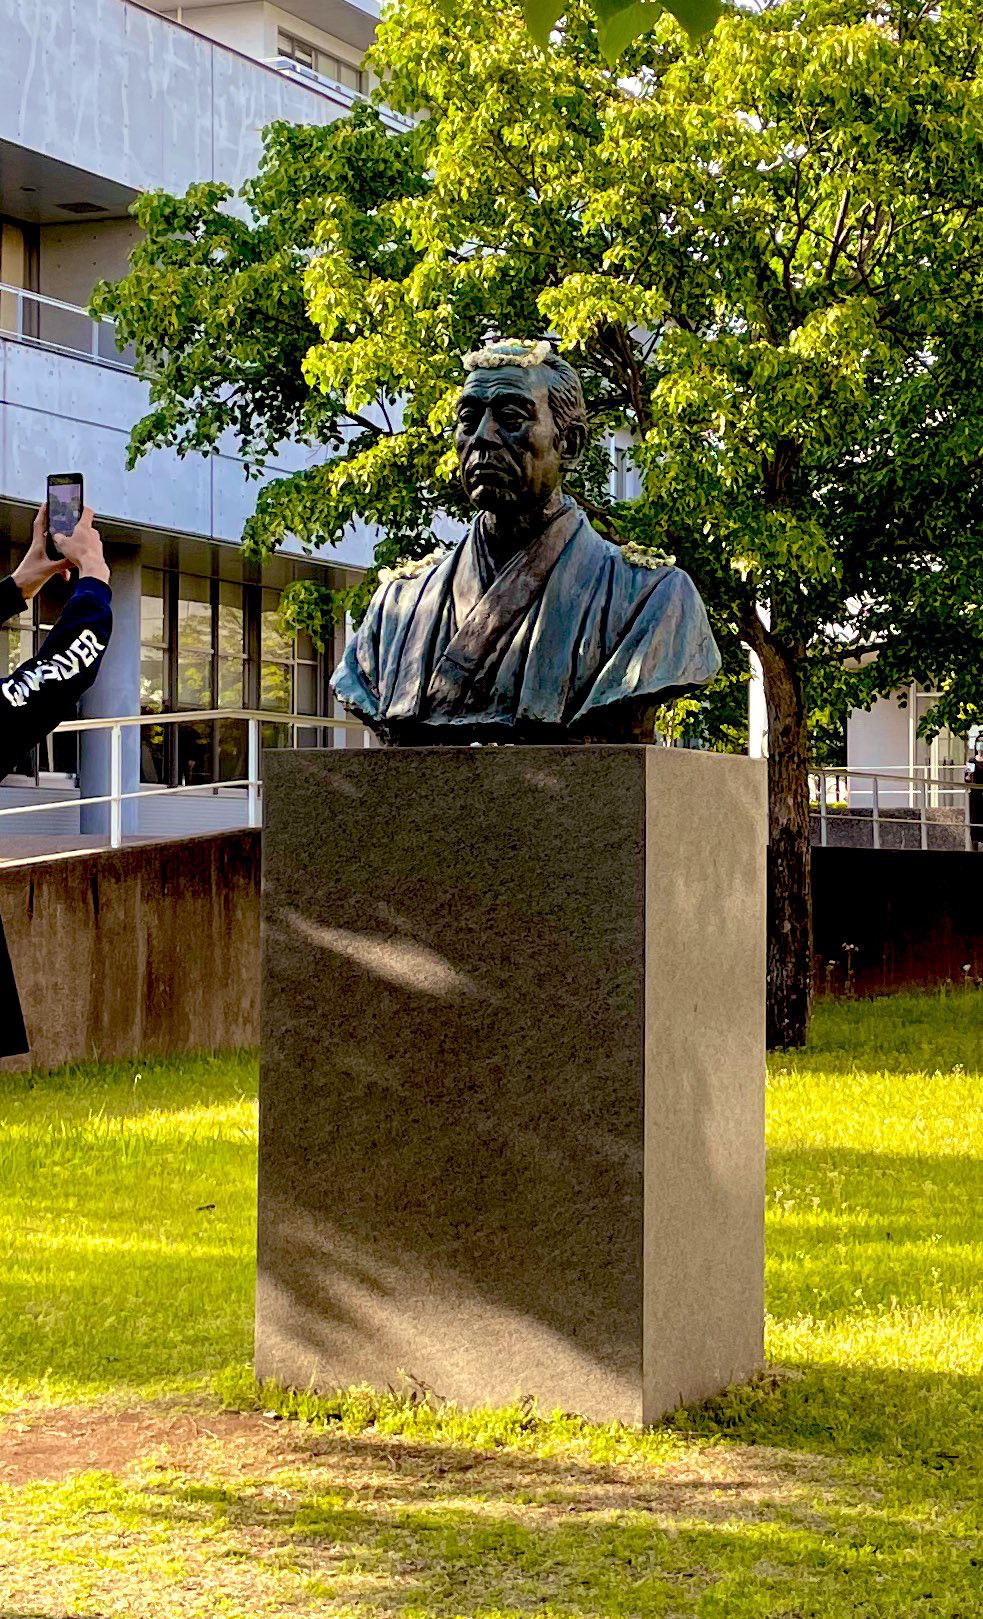

公園のベンチに男性が座っています。</s>
公園のベンチに銅像が座っています。</s>
公園のベンチに男性が座って銅像を見ています。</s>
男性が銅像の横に立ってポーズをとっています。</s>
男性が銅像の横に立っています。</s>


In [16]:
# キャプション生成
pil_image, captions = coco_predictor.caption(image_fpath=image_fpath, beam_size=5)
display(pil_image) # 画像を表示
print(*captions, sep="\n") # キャプションを表示

# 2 SFCOCO2022でfine-tuningしたモデル

## 2.1 学習済みモデルのダウンロード

In [10]:
_ = hf_hub_download(repo_id=pretrained_repo_id, filename="coco_based-sfcoco2022-gpt_medium-en_clip_b32-transformer-finetune-ep20-bs8-lr2e-05/args.json")
sfcoco2022_checkpoint_fpath = hf_hub_download(repo_id=pretrained_repo_id, filename="coco_based-sfcoco2022-gpt_medium-en_clip_b32-transformer-finetune-ep20-bs8-lr2e-05/011.pt")

Downloading:   0%|          | 0.00/869 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.66G [00:00<?, ?B/s]

## 2.2 学習済みモデルの読み込み

In [ ]:
cap_model, cap_tokenizer, clip_model, clip_preprocess = build_models_from_pretrained(sfcoco2022_checkpoint_fpath)
sfcoco2022_predictor = Predictor(cap_model=cap_model, cap_tokenizer=cap_tokenizer,
                                 clip_model=clip_model, clip_preprocess=clip_preprocess)

## 2.3 テスト画像の選択

In [ ]:
#@markdown ### 好きな画像をアップロードする場合
#@markdown ローカルにある画像を使いたい場合は，このセルを実行してアップロードしてください．
#@markdown アップロードした画像はカレントディレクトリ直下に吐き出されます．

image_fpath = upload_file()

In [ ]:
#@markdown ### テスト画像リストから選ぶ場合
#@markdown テスト画像リストの画像を使用する場合は，このセルを実行して1枚選択してください．

# テスト画像ファイルリスト読込
TEST_IMAGE_FNAME_LIST = json.load(open("data/sfcoco2021/processed-en_clip_b32/test_list.json"))

# 1枚選択
image_fname = TEST_IMAGE_FNAME_LIST[1] # 1は福沢諭吉像
# image_fname = random.choice(TEST_IMAGE_FNAME_LIST)

image_fpath = os.path.join("data/sfcoco2021/images", image_fname)

## 2.4 キャプション生成

In [ ]:
# キャプション生成
pil_image, captions = sfcoco2022_predictor.caption(image_fpath=image_fpath, beam_size=5)
display(pil_image) # 画像を表示
print(*captions, sep="\n") # キャプションを表示

# 3 SFCOCO2021+2022でfine-tuningしたモデル

## 2.1 学習済みモデルのダウンロード

In [11]:
_ = hf_hub_download(repo_id=pretrained_repo_id, filename="coco_based-sfcoco_merged-gpt_medium-en_clip_b32-transformer-finetune-ep20-bs8-lr2e-05/args.json")
sfcoco2022_checkpoint_fpath = hf_hub_download(repo_id=pretrained_repo_id, filename="coco_based-sfcoco_merged-gpt_medium-en_clip_b32-transformer-finetune-ep20-bs8-lr2e-05/009.pt")

Downloading:   0%|          | 0.00/878 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.66G [00:00<?, ?B/s]

## 2.2 学習済みモデルの読み込み

In [ ]:
cap_model, cap_tokenizer, clip_model, clip_preprocess = build_models_from_pretrained(pretrained_fpath)
sfcoco_merged_predictor = Predictor(cap_model=cap_model, cap_tokenizer=cap_tokenizer,
                                    clip_model=clip_model, clip_preprocess=clip_preprocess)

## 2.3 テスト画像の選択

In [ ]:
#@markdown ### 好きな画像をアップロードする場合
#@markdown ローカルにある画像を使いたい場合は，このセルを実行してアップロードしてください．
#@markdown アップロードした画像はカレントディレクトリ直下に吐き出されます．

image_fpath = upload_file()

In [ ]:
#@markdown ### テスト画像リストから選ぶ場合
#@markdown テスト画像リストの画像を使用する場合は，このセルを実行して1枚選択してください．

# テスト画像ファイルリスト読込
TEST_IMAGE_FNAME_LIST = json.load(open("data/sfcoco2021/processed-en_clip_b32/test_list.json"))

# 1枚選択
image_fname = TEST_IMAGE_FNAME_LIST[1] # 1は福沢諭吉像
# image_fname = random.choice(TEST_IMAGE_FNAME_LIST)

image_fpath = os.path.join("data/sfcoco2021/images", image_fname)

## 2.4 キャプション生成

In [ ]:
# キャプション生成
pil_image, captions = sfcoco2022_predictor.caption(image_fpath=image_fpath, beam_size=5)
display(pil_image) # 画像を表示
print(*captions, sep="\n") # キャプションを表示